In [1]:
import glob

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import xarray as xr
import xclim as xc
import numpy as np
import cmocean
import geopandas as gp

from unseen import fileio

Matplotlib is building the font cache; this may take a moment.


## Shapefile

In [2]:
river_regions_file = '/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/river_regions/river_regions.shp'
river_regions = gp.read_file(river_regions_file)

In [7]:
river_regions['Division'].unique()

array(['Tanami-Timor Sea Coast', 'South Western Plateau',
       'South West Coast', 'South East Coast (NSW)', 'North East Coast',
       'Lake Eyre Basin', 'Tasmania', 'Carpentaria Coast',
       'South East Coast (Victoria)', 'South Australian Gulf',
       'Pilbara-Gascoyne', 'North Western Plateau',
       'Murray-Darling Basin'], dtype=object)

In [8]:
sec_river_regions = river_regions[river_regions['Division'] == 'South East Coast (NSW)']
sec_river_regions

,RivRegName,RivRegNum,Division,geometry
42,MACQUARIE-TUGGERAH LAKES,11,South East Coast (NSW),"MULTIPOLYGON (((151.50403 -33.36069, 151.50403..."
43,HAWKESBURY RIVER,12,South East Coast (NSW),"MULTIPOLYGON (((150.32181 -34.64903, 150.32208..."
44,SYDNEY COAST-GEORGES RIVER,13,South East Coast (NSW),"MULTIPOLYGON (((151.01514 -34.08736, 151.01542..."
45,WOLLONGONG COAST,14,South East Coast (NSW),"MULTIPOLYGON (((150.69486 -34.62292, 150.69486..."
46,SHOALHAVEN RIVER,15,South East Coast (NSW),"MULTIPOLYGON (((149.54847 -35.99542, 149.54875..."
47,CLYDE RIVER-JERVIS BAY,16,South East Coast (NSW),"MULTIPOLYGON (((150.18542 -35.83375, 150.18542..."
48,MORUYA RIVER,17,South East Coast (NSW),"POLYGON ((149.74986 -35.53264, 149.74986 -35.5..."
49,TUROSS RIVER,18,South East Coast (NSW),"MULTIPOLYGON (((150.23014 -36.24264, 150.23014..."
50,BEGA RIVER,19,South East Coast (NSW),"POLYGON ((149.62986 -36.84486, 149.62986 -36.8..."
51,TOWAMBA RIVER,20,South East Coast (NSW),"MULTIPOLYGON (((149.92208 -37.04625, 149.92236..."


In [23]:
lgas_file = '/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/aus_local_gov/aus_local_gov.shp'
lgas = gp.read_file(lgas_file)

In [25]:
nsw_lgas = lgas[lgas['STE_NAME21'] == 'New South Wales']

In [26]:
nsw_lgas

,LGA_CODE22,LGA_NAME22,STE_CODE21,STE_NAME21,AREASQKM,LOCI_URI21,SHAPE_Leng,SHAPE_Area,geometry
0,10050,Albury,1,New South Wales,305.6386,https://linked.data.gov.au/dataset/asgsed3/LGA...,1.321768,0.030560,"POLYGON ((146.86566 -36.07292, 146.86512 -36.0..."
1,10180,Armidale,1,New South Wales,7809.4406,https://linked.data.gov.au/dataset/asgsed3/LGA...,6.034583,0.732825,"POLYGON ((152.38816 -30.52639, 152.38812 -30.5..."
2,10250,Ballina,1,New South Wales,484.9692,https://linked.data.gov.au/dataset/asgsed3/LGA...,1.511121,0.044843,"MULTIPOLYGON (((153.57106 -28.87381, 153.57106..."
3,10300,Balranald,1,New South Wales,21690.7493,https://linked.data.gov.au/dataset/asgsed3/LGA...,11.489912,2.115528,"POLYGON ((143.00433 -33.78164, 143.01538 -33.7..."
4,10470,Bathurst,1,New South Wales,3817.8645,https://linked.data.gov.au/dataset/asgsed3/LGA...,5.395114,0.370149,"POLYGON ((149.84877 -33.52784, 149.84864 -33.5..."
...,...,...,...,...,...,...,...,...,...
124,18400,Wollondilly,1,New South Wales,2555.4341,https://linked.data.gov.au/dataset/asgsed3/LGA...,3.850332,0.249665,"POLYGON ((150.3406 -33.85652, 150.34101 -33.85..."
125,18450,Wollongong,1,New South Wales,684.3076,https://linked.data.gov.au/dataset/asgsed3/LGA...,2.153309,0.067065,"MULTIPOLYGON (((150.9366 -34.49454, 150.93658 ..."
126,18500,Woollahra,1,New South Wales,12.2584,https://linked.data.gov.au/dataset/asgsed3/LGA...,0.299721,0.001194,"MULTIPOLYGON (((151.28159 -33.83318, 151.28151..."
127,18710,Yass Valley,1,New South Wales,3995.0170,https://linked.data.gov.au/dataset/asgsed3/LGA...,3.985129,0.394254,"POLYGON ((148.58152 -34.80679, 148.58153 -34.8..."


In [42]:
nsw_lgas['LGA_NAME22'].unique()

array(['Albury', 'Armidale', 'Ballina', 'Balranald', 'Bathurst',
       'Bayside (NSW)', 'Bega Valley', 'Bellingen', 'Berrigan',
       'Blacktown', 'Bland', 'Blayney', 'Blue Mountains', 'Bogan',
       'Bourke', 'Brewarrina', 'Broken Hill', 'Burwood', 'Byron',
       'Cabonne', 'Camden', 'Campbelltown (NSW)', 'Canada Bay',
       'Canterbury-Bankstown', 'Carrathool', 'Central Coast (NSW)',
       'Central Darling', 'Cessnock', 'Clarence Valley', 'Cobar',
       'Coffs Harbour', 'Coolamon', 'Coonamble', 'Cootamundra-Gundagai',
       'Cowra', 'Cumberland', 'Dubbo', 'Dungog', 'Edward River',
       'Eurobodalla', 'Fairfield', 'Federation', 'Forbes',
       'Georges River', 'Gilgandra', 'Glen Innes Severn',
       'Goulburn Mulwaree', 'Greater Hume', 'Griffith', 'Gunnedah',
       'Gwydir', 'Hawkesbury', 'Hay', 'Hilltops', 'Hornsby',
       'Hunters Hill', 'Inner West', 'Inverell', 'Junee', 'Kempsey',
       'Kiama', 'Ku-ring-gai', 'Kyogle', 'Lachlan', 'Lake Macquarie',
       'Lane Cove

## Day-by-day rainfall

In [9]:
agcd_file = '/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_20070101-20071231_daily.nc'

In [10]:
ds = xr.open_dataset(agcd_file)

/jobfs/148165618.gadi-pbs/ipykernel_3421732/762140172.py:10: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in p.axes.flat:


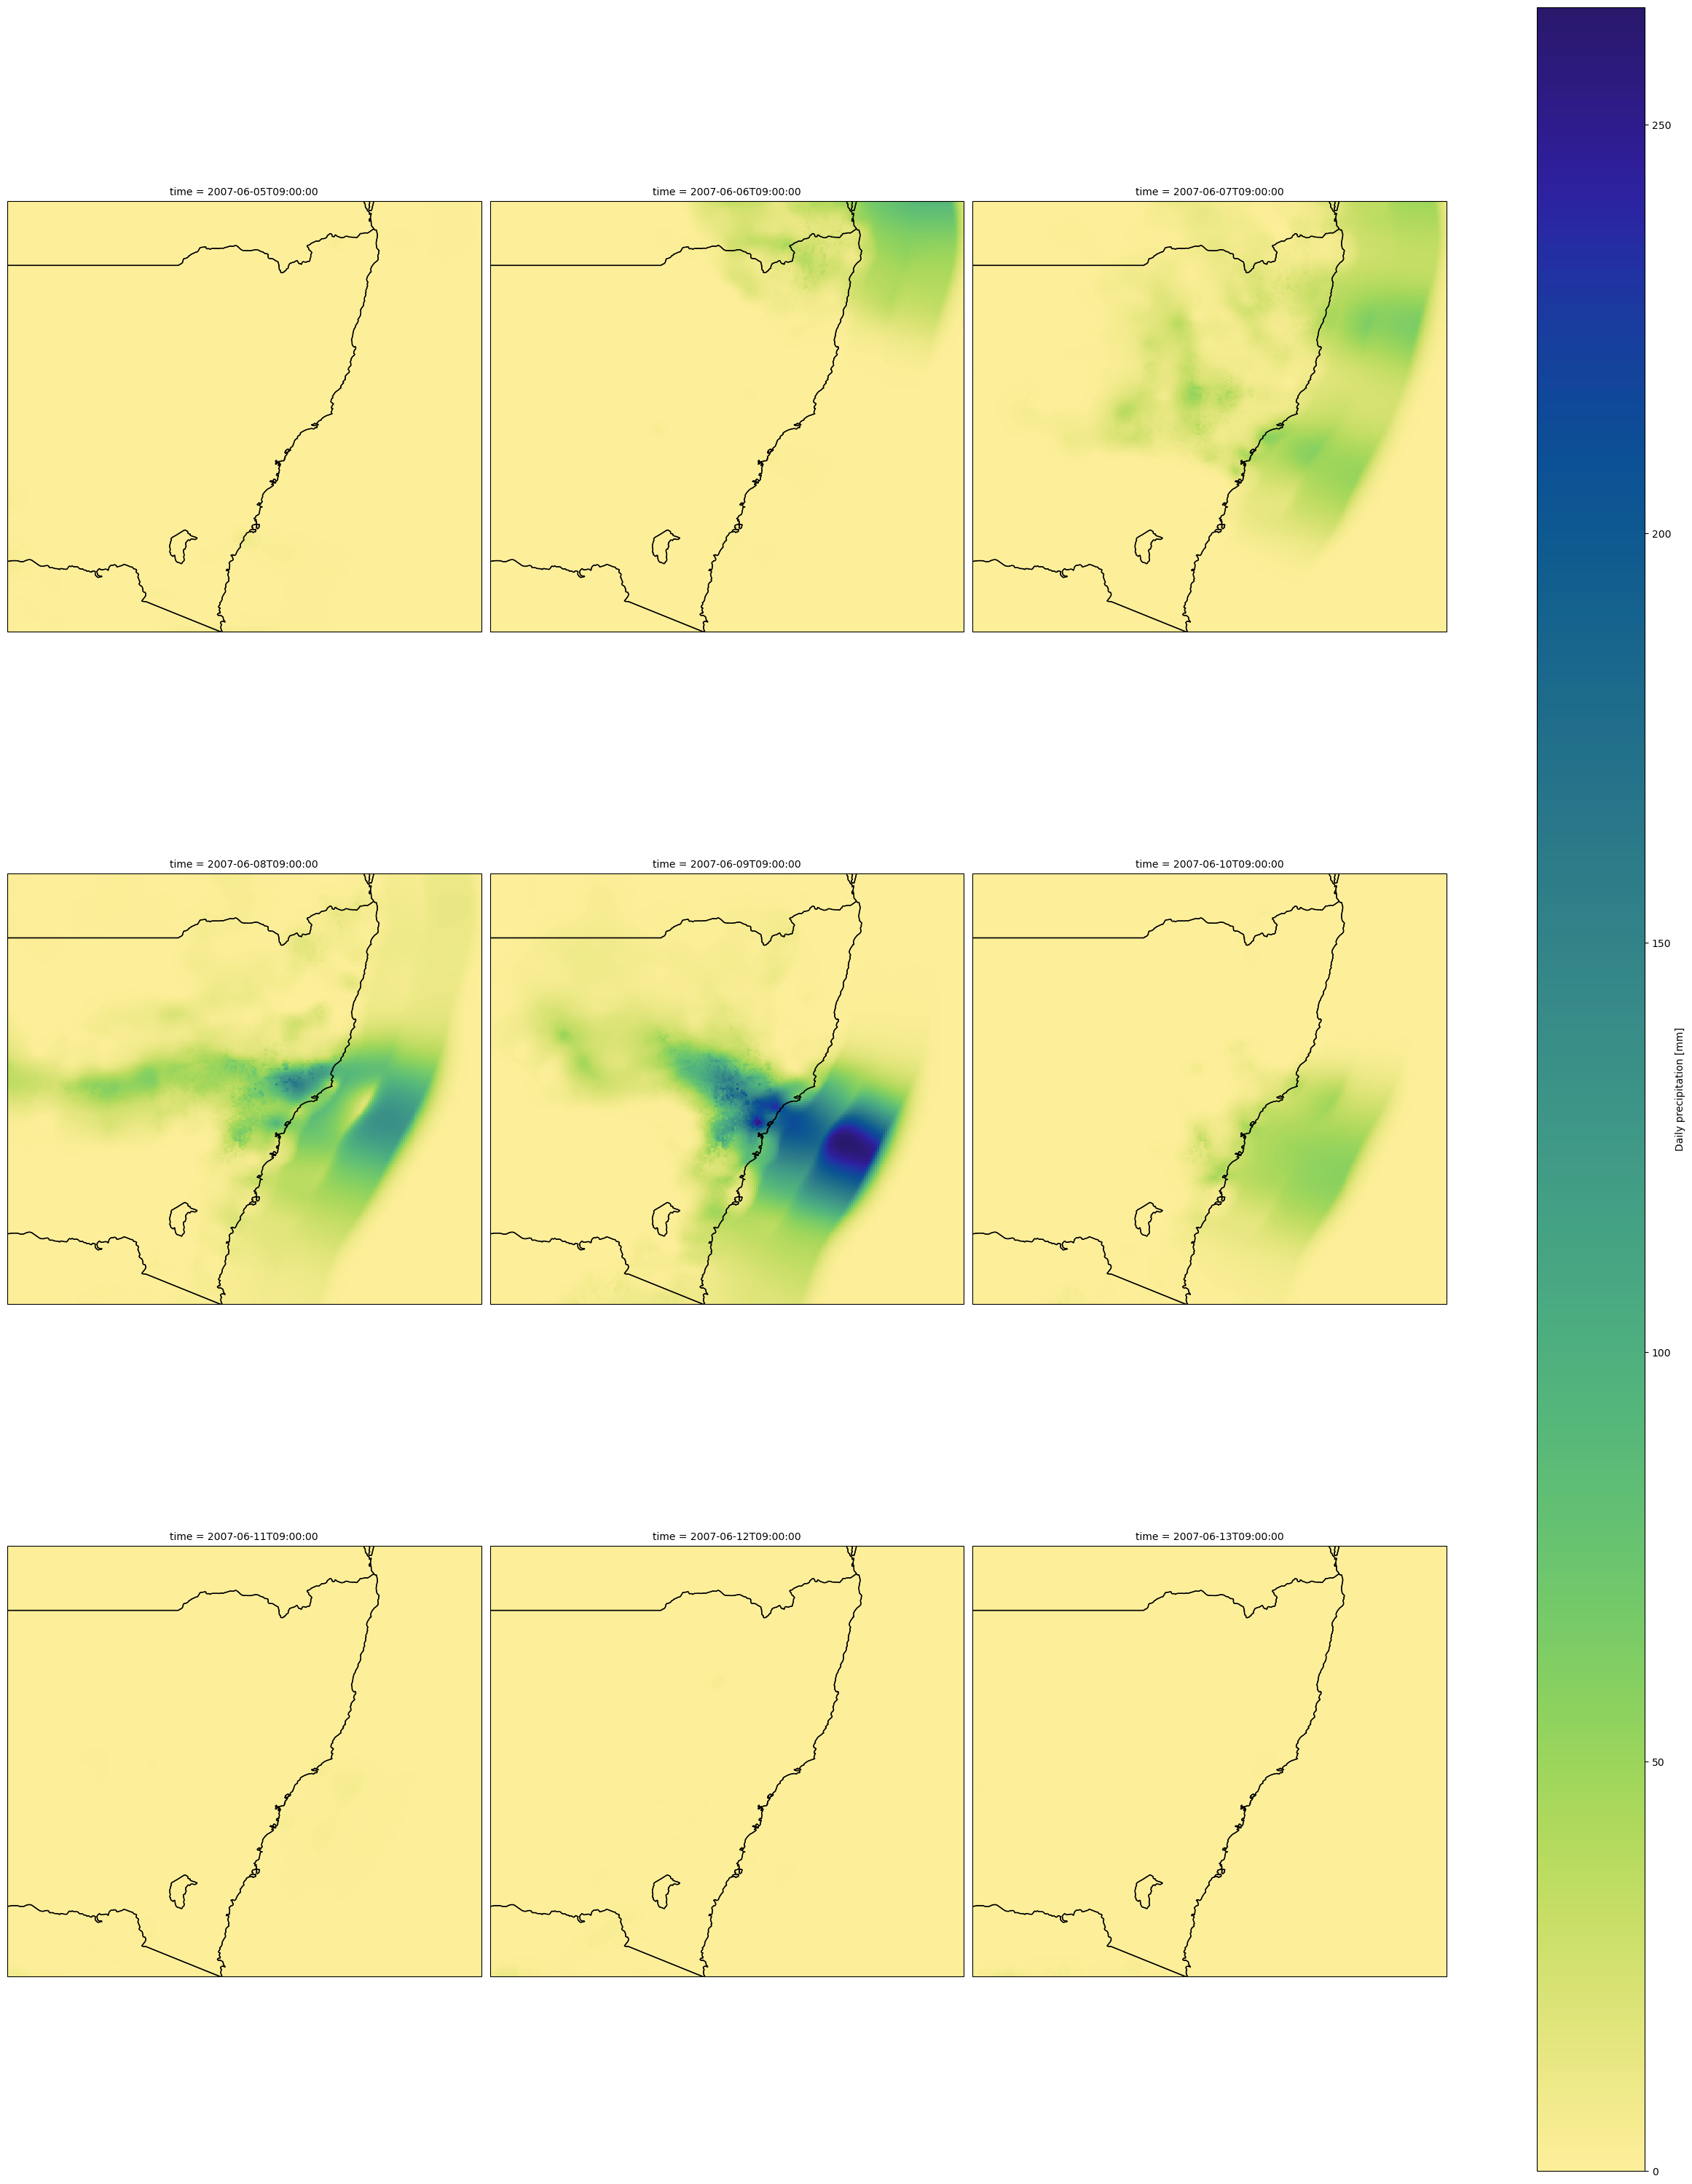

In [14]:
p = ds['precip'].sel(time=slice('2007-06-05', '2007-06-13')).plot(
    col='time',
    col_wrap=3,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.haline_r,
    figsize=[25, 30],
    subplot_kws={"projection": ccrs.PlateCarree()},
)

for ax in p.axes.flat:
    ax.coastlines()
    ax.add_feature(cartopy.feature.STATES)
    ax.set_extent([145, 156, -27.5, -37.5], crs=ccrs.PlateCarree())

#plt.savefig(
#    'jasper_day-by-day.png',
#    bbox_inches='tight',
#    facecolor='white',
#    dpi=100
#)
plt.show()

## Event summary

In [15]:
ds_masked = fileio.open_dataset(
    agcd_file,
    shapefile='/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp'
)
precip_total_masked = ds_masked['precip'].sel(time=slice('2007-06-08', '2007-06-09')).sum(dim=['time'], min_count=1)

In [58]:
def plot_cities(ax, label_color='white'):
    lats = [-32.9, -33.9]
    lons = [151.8, 151.2]
    cities = ['Newcastle', 'Sydney']
    for lon, lat, city in zip(lons, lats, cities):
        ax.plot(lon, lat, 'ro', zorder=5, transform=ccrs.PlateCarree())
        ax.text(
            lon + 0.2,
            lat,
            city,
            fontsize='large',
            color=label_color,
            transform=ccrs.PlateCarree()
        )

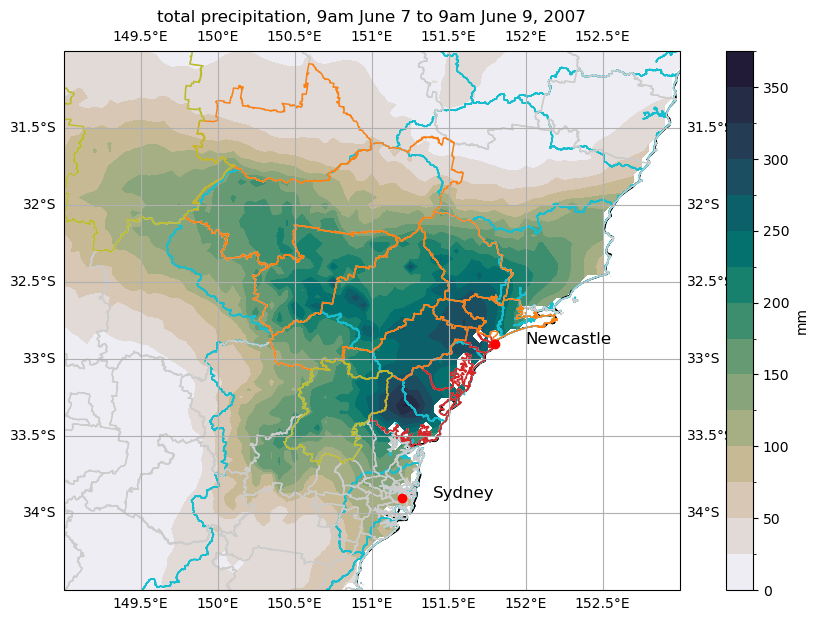

In [62]:
fig = plt.figure(figsize=[12, 7])
ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
lw = 1.0
pr_levels = np.arange(0, 400, 25)
cmap = cmocean.cm.rain
# cmocean.cm.haline_r

precip_total_masked.plot.contourf(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    levels=pr_levels,
    cbar_kwargs={'label': 'mm'},
)
ax1.coastlines()

# State boundaries
ax1.add_feature(cartopy.feature.STATES)

# River catchment boundaries 
ax1.add_geometries(
    sec_river_regions.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    linewidth=lw,
    edgecolor='tab:cyan',
)
#ax1.add_geometries(
#    sec_river_regions[sec_river_regions['RivRegName'] == 'HUNTER RIVER'].geometry,
#    ccrs.PlateCarree(),
#    facecolor='none',
#    linewidth=lw,
#    edgecolor='tab:cyan',
#)
#ax1.add_geometries(
#    sec_river_regions[sec_river_regions['RivRegName'] == 'MACQUARIE-TUGGERAH LAKES'].geometry,
#    ccrs.PlateCarree(),
#    facecolor='none',
#    linewidth=lw,
#    edgecolor='tab:cyan',
#)

# Local government areas
ax1.add_geometries(
    nsw_lgas.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    linewidth=lw,
    edgecolor='0.8',
)
most_impacted_lgas = ['Newcastle', 'Lake Macquarie', 'Central Coast (NSW)']
for lga in most_impacted_lgas:
    ax1.add_geometries(
        nsw_lgas[nsw_lgas['LGA_NAME22'] == lga].geometry,
        ccrs.PlateCarree(),
        facecolor='none',
        linewidth=lw,
        edgecolor='tab:red',
    )

natural_disaster_lgas_8June = [
    'Liverpool Plains',
    'Upper Hunter',
#    'Gloucester',
    'Dungog',
    'Singleton',
    'Muswellbrook',
    'Maitland',
    'Port Stephens',
    'Cessnock',
]
for lga in natural_disaster_lgas_8June:
    ax1.add_geometries(
        nsw_lgas[nsw_lgas['LGA_NAME22'] == lga].geometry,
        ccrs.PlateCarree(),
        facecolor='none',
        linewidth=lw,
        edgecolor='tab:orange',
    )

natural_disaster_lgas_14June = [
    'Hawkesbury',
    'Warrumbungle',
    'Gilandra'
]
for lga in natural_disaster_lgas_14June:
    ax1.add_geometries(
        nsw_lgas[nsw_lgas['LGA_NAME22'] == lga].geometry,
        ccrs.PlateCarree(),
        facecolor='none',
        linewidth=lw,
        edgecolor='tab:olive',
    )
ax1.gridlines(draw_labels=True)
#ax1.plot(
#    [145, 145, 146, 146, 145],
#    [-15.5, -17.5, -17.5, -15.5, -15.5],
#    transform=ccrs.PlateCarree(),
#    color='black',
#    linestyle=':'
#)

ax1.set_extent([149, 153, -31, -34.5], crs=ccrs.PlateCarree())
plot_cities(ax1, label_color='black')
ax1.set_title('total precipitation, 9am June 7 to 9am June 9, 2007')

plt.savefig(
    'pasha_event.png',
    bbox_inches='tight',
    facecolor='white',
    dpi=300
)
plt.show()